# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
import os
from pathlib import Path

# 2. Read the data

In [2]:
# Determining the data path
BASE_DIR = Path.cwd()
while not (BASE_DIR / "dataset").exists():
    BASE_DIR = BASE_DIR.parent
data_path = BASE_DIR / "dataset" / "clean_house_prices_df.csv"

house_prices_df = pd.read_csv(data_path)

# 3. Exploratory Data Analysis

## 3.1. Univariate Analysis

### 3.1.1. Numerical Features - Analysis

#### 1. Amount(in rupees)

In [3]:
house_prices_df.select_dtypes(include="number").columns

Index(['Amount(in rupees)', 'Bathroom', 'Balcony', 'Super Area', 'BHK',
       'Current_Floor', 'Total_Floors', 'View_Garden_Park', 'View_Main_Road',
       'View_Pool', 'View_Unknown'],
      dtype='object')

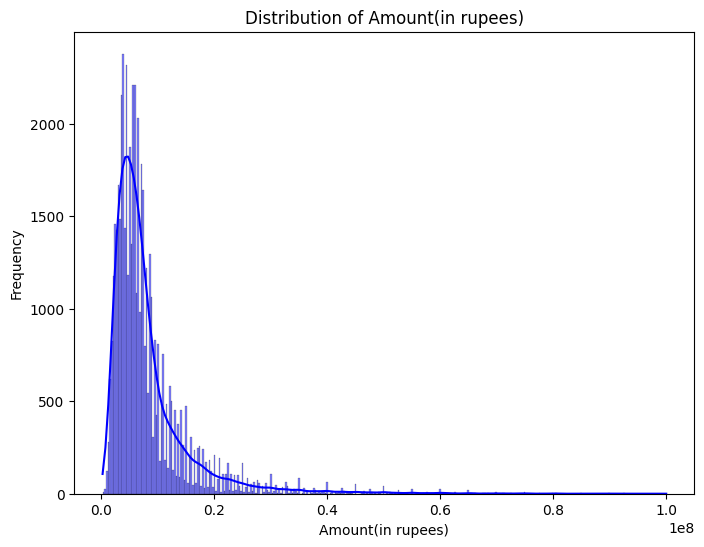

In [4]:
plt.figure(figsize=(8,6))
sns.histplot(data=house_prices_df, x="Amount(in rupees)",kde=True, color="blue")
plt.title("Distribution of Amount(in rupees)")
plt.ylabel('Frequency')
plt.show()

##### 📊 Insights on Price Distribution

- **Right-Skewed Distribution:**  
  The data is clearly right-skewed. Most properties are in the low to mid price range, while fewer properties have very high prices.

- **Luxury Long Tail:**  
  There is a long tail on the right side of the distribution.  
  This represents expensive properties (like luxury villas and penthouses).  
  These values are real and important, not errors.

- **Modeling Impact:**  
  Because of this skewness, we may prefer using **non-linear models** (like tree-based models) instead of linear models, since they can handle skewed data better without needing heavy transformations.

#### 2. Super Area

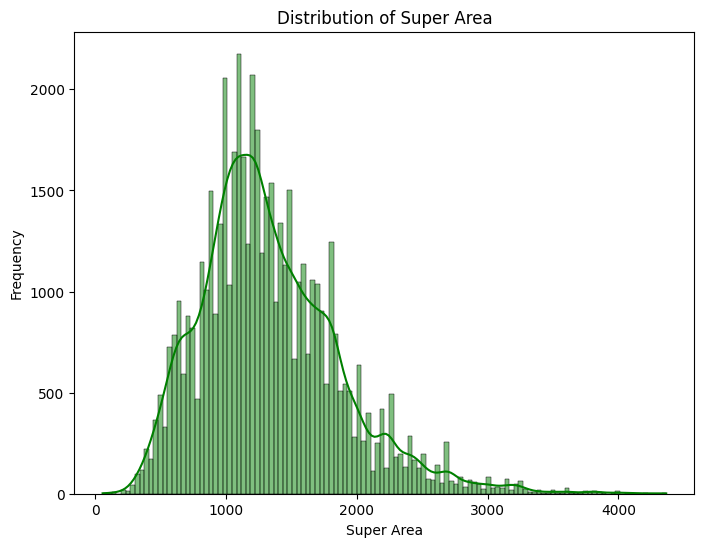

In [5]:
plt.figure(figsize=(8,6))
sns.histplot(data=house_prices_df, x="Super Area",kde=True, color="green")
plt.title("Distribution of Super Area")
plt.ylabel('Frequency')
plt.show()

##### 📐 Insights on Super Area Distribution

- **Slight Right-Skewed Distribution:**  
  The data is slightly right-skewed. Most properties have a medium area size, while fewer properties have very large areas.

- **Concentration in Mid-Range:**  
  Most values are concentrated between around 800 and 1800 sq.ft.  
  This shows that the majority of properties fall in a common, practical size range.

- **Large Area Tail:**  
  There is a small tail on the right side representing larger properties.  
  These are likely luxury homes or villas, and they are valid data points.

- **Modeling Impact:**  
  The distribution is relatively well-behaved compared to price, so most models (including linear models) can handle it.  
  No strong transformation is required, but scaling may still help improve performance.

#### 3. BHK

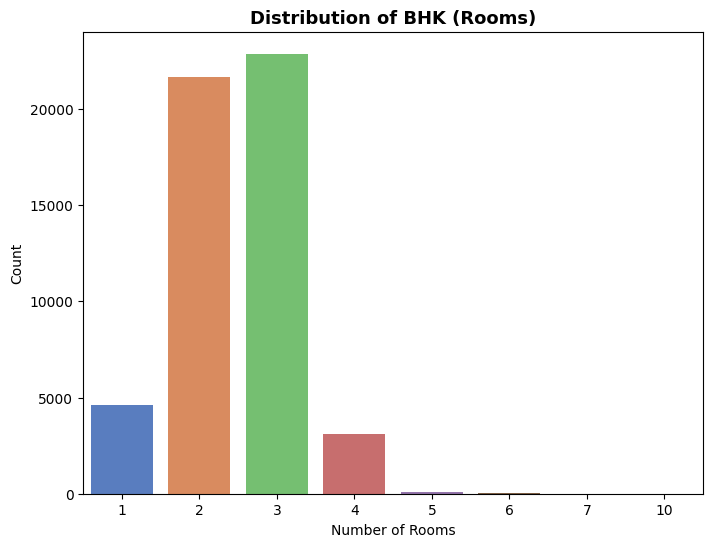

In [6]:
plt.figure(figsize=(8,6))
sns.countplot(data=house_prices_df, x="BHK", palette="muted")
plt.title('Distribution of BHK (Rooms)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Rooms')
plt.ylabel('Count')
plt.show()

##### **Insights on Structural Layouts (BHK):**

- **The 2 & 3 BHK Core Market:**  
  The `BHK` distribution shows that **2 BHK and 3 BHK** properties dominate the market.  
  This indicates that most buyers are looking for standard family-sized homes.  
  Smaller units (1 BHK) and larger luxury homes (4+ BHK) form a smaller portion of the market.

#### 4. Bathroom

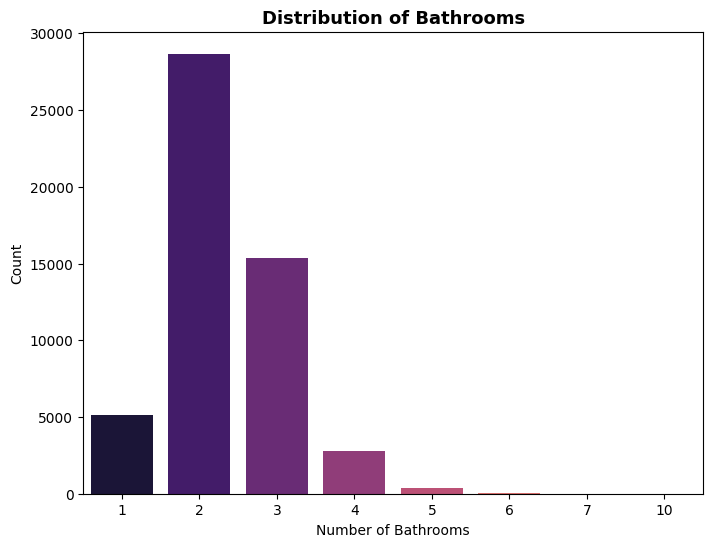

In [7]:
plt.figure(figsize=(8,6))
sns.countplot(x='Bathroom', data=house_prices_df, palette='magma')
plt.title('Distribution of Bathrooms', fontsize=13, fontweight='bold')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.show()

##### **Insights on Structural Layouts (Bathrooms):**

- **Bathroom to BHK Relationship:**  
  The `Bathroom` distribution closely follows the BHK pattern, with most properties having **2 or 3 bathrooms**.  
  This suggests a strong relationship between rooms and bathrooms, where homes usually have a near 1-to-1 ratio.

#### 5. Balcony

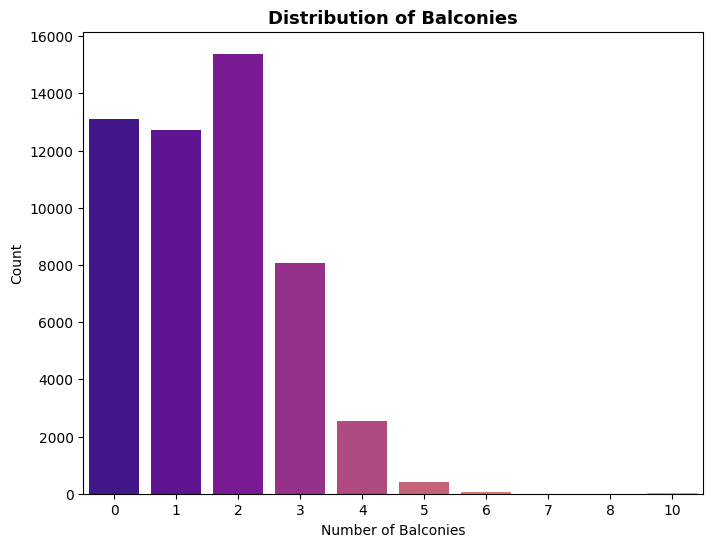

In [8]:
plt.figure(figsize=(8,6))
sns.countplot(x='Balcony', data=house_prices_df, palette='plasma')
plt.title('Distribution of Balconies', fontsize=13, fontweight='bold')
plt.xlabel('Number of Balconies')
plt.ylabel('Count')
plt.show()

##### **Insights on Structural Layouts (Balconies):**

- **Balcony Supply Pattern:**  
  The `Balcony` distribution peaks at **1 and 2 balconies**, with 3 balconies also being common.  
  This shows that having at least one or two balconies is standard in most properties.  
  Properties with no balconies or a very high number of balconies are rare.

##### 📊 Business Logic & Data Cleaning Insights

We did not use standard statistical methods (like IQR) for **BHK, Bathroom, and Balcony**. Instead, we cleaned the data using **Real-World Housing Logic (Domain Knowledge)** based on these findings:

---

##### 🏠 1. BHK (Rooms) & Balcony Limits

* **What we saw (Observation):**
  Most houses in the dataset have:
  * `1 to 4 BHK` (Bedrooms)
  * `0 to 4 Balconies`

* **The Problem (Outliers):**
  Some rows have extreme values like `10 BHK` or `10 Balconies`. These numbers stand alone at the end of our charts.

* **What it means (Interpretation):**
  These numbers are not realistic for normal apartments. They are mostly:
  * Typing errors (Data entry errors)
  * System bugs or scraping mistakes

* **Our Action:**
  We set clean and logical upper limits to keep only real housing shapes:
  ```text
  BHK ≤ 6
  Balcony ≤ 5


In [9]:
house_prices_df.shape

(52348, 17)

In [10]:
# Domain-driven data cleaning based on real estate logic
house_prices_df = house_prices_df[
    (house_prices_df['BHK'] <= 6) & 
    (house_prices_df['Bathroom'] <= house_prices_df['BHK'] + 1) &
    (house_prices_df['Balcony'] <= 5)
]

In [11]:
house_prices_df.shape

(52212, 17)

#### 6. Current Floor

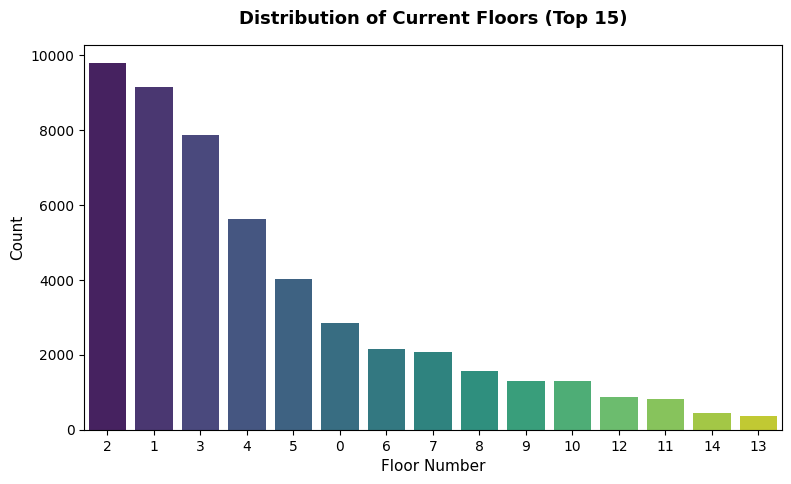

In [12]:
plt.figure(figsize=(9, 5))
top_current_floors = house_prices_df['Current_Floor'].value_counts().head(15)
sns.barplot(x=top_current_floors.index, y=top_current_floors.values, palette='viridis',
            order=top_current_floors.index)

plt.title('Distribution of Current Floors (Top 15)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Floor Number', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.show()

##### 🏢 Current Floor Distribution — Insights

- Most properties are located on **low to mid floors (1–5)**, especially floors **2 and 3**.
- Very high floors (10+) are much less common.
- Floor **0 (ground floor)** also appears but less than typical floors.
- The distribution is **right-skewed** (more low floors, fewer high floors).

📌 **Business Insight:**
Buyers mostly prefer lower and mid floors, likely due to:
- easier access  
- lower cost  
- less dependency on elevators  

📌 **Modeling Insight:**
Floor number is an important **numerical feature** and may impact price.

#### 7. Total Floors

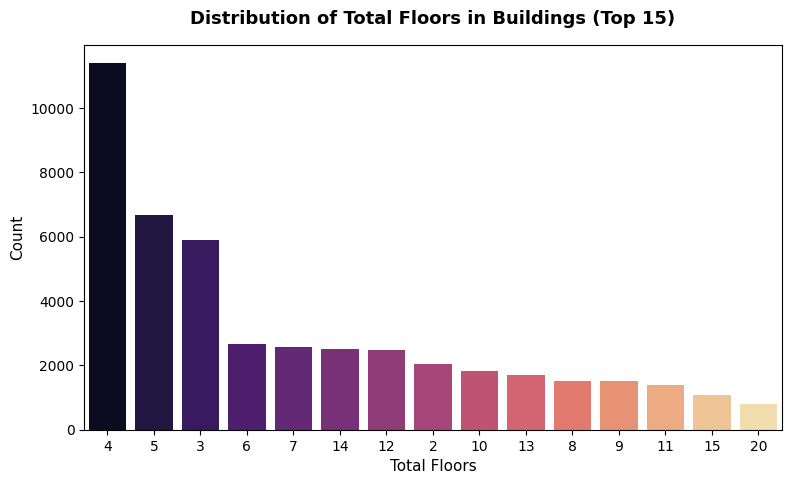

In [13]:
plt.figure(figsize=(9, 5))
top_total_floors = house_prices_df['Total_Floors'].value_counts().head(15)
sns.barplot(x=top_total_floors.index, y=top_total_floors.values, palette='magma',
            order=top_total_floors.index)
plt.title('Distribution of Total Floors in Buildings (Top 15)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total Floors', fontsize=11)
plt.ylabel('Count', fontsize=11)

plt.show()

##### 🏗️ Total Floors in Buildings — Insights

- Most buildings have **3 to 5 floors**, with **4 floors** being the most common.
- High-rise buildings (10+ floors) exist but are less frequent.
- The data shows a mix of **low-rise and mid-rise buildings**, not dominated by skyscrapers.

📌 **Business Insight:**
The market is mostly **low to mid-rise residential**, not high-rise luxury towers.

📌 **Modeling Insight:**
Total floors can affect price and should be used as a feature, especially with interaction (e.g., floor / total floors).

### 3.1.2. Categorical Features - Analysis

#### 1. Furnishing

In [14]:
house_prices_df['Furnishing'].value_counts()

Furnishing
Semi-Furnished    23321
Unfurnished       22107
Furnished          6784
Name: count, dtype: int64

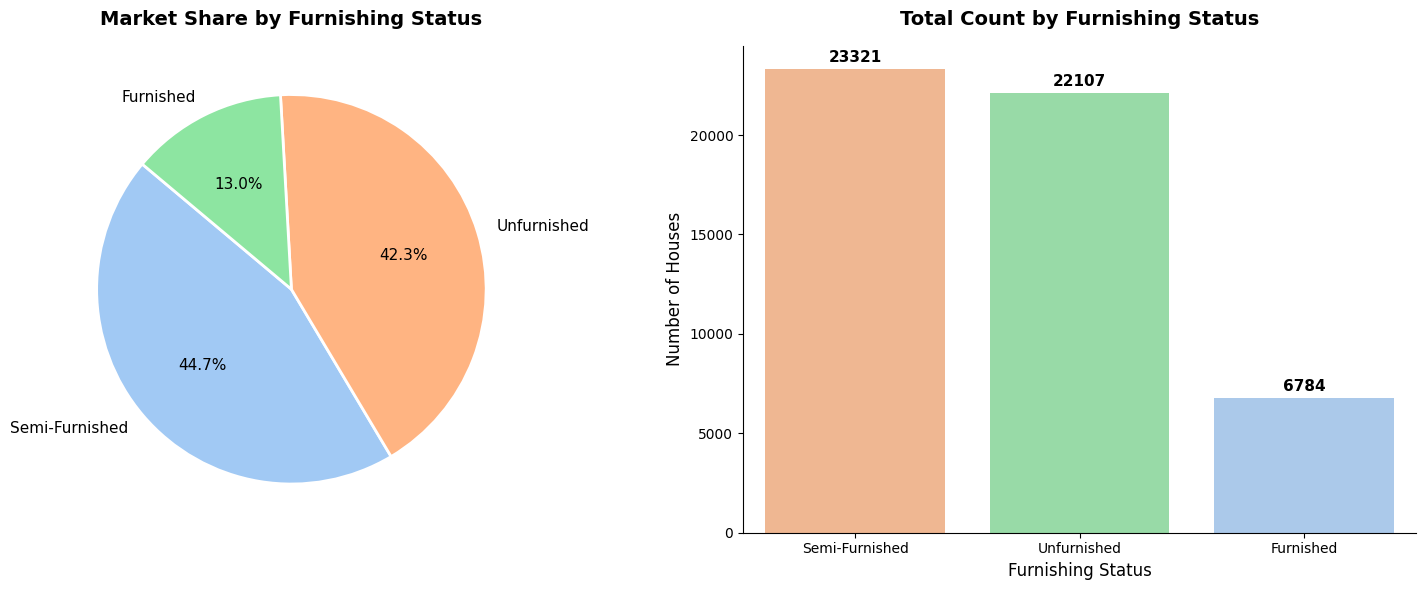

In [15]:
furnishing_counts = house_prices_df['Furnishing'].value_counts()
custom_colors = sns.color_palette('pastel')[0:len(furnishing_counts)]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.pie(
    furnishing_counts, 
    labels=furnishing_counts.index, 
    autopct='%1.1f%%', 
    colors=custom_colors, 
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
plt.title('Market Share by Furnishing Status', fontsize=14, fontweight='bold', pad=15)

plt.subplot(1, 2, 2)
ax = sns.countplot(
    data=house_prices_df, 
    x="Furnishing", 
    hue="Furnishing",
    palette=custom_colors, 
    order=furnishing_counts.index,
    legend=False 
)

for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold', padding=3)

plt.title('Total Count by Furnishing Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Furnishing Status', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

##### 🪑 Insights on Furnishing Status

- **Market Distribution:**  
  Most properties are **Semi-Furnished (~44.7%)** or **Unfurnished (~42.3%)**,  
  while **Furnished (~13%)** properties are much fewer.

- **Buyer Behavior Insight:**  
  This suggests that many buyers prefer homes that are not fully furnished,  
  giving them more flexibility to design or furnish the space as they like.

- **Class Balance:**  
  The data is fairly balanced between Semi-Furnished and Unfurnished,  
  but Furnished properties are underrepresented.

#### 2. Status

In [16]:
house_prices_df["Status"].value_counts()

Status
Ready to Move    52212
Name: count, dtype: int64

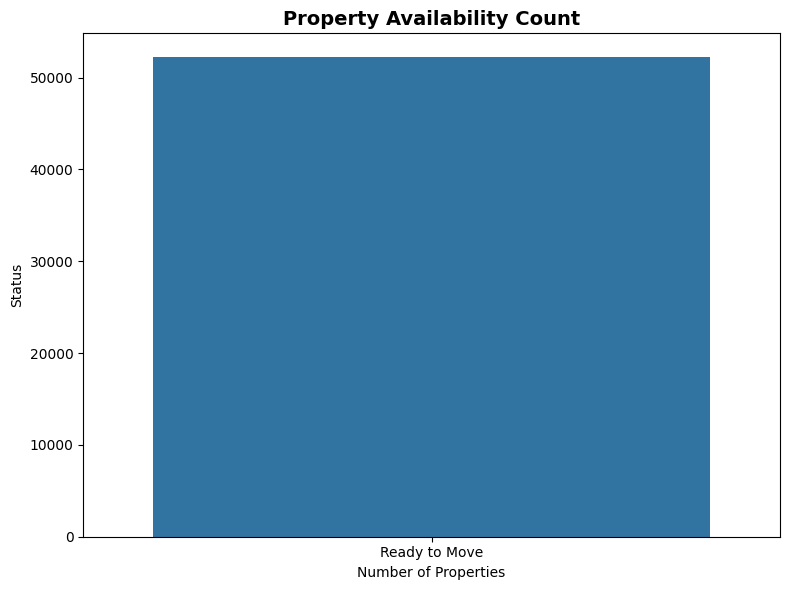

In [17]:
plt.figure(figsize=(8,6))
sns.countplot(x='Status', data=house_prices_df, 
              hue="Status", order=house_prices_df['Status'].value_counts().index)
plt.title('Property Availability Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Properties')
plt.ylabel('Status')

plt.tight_layout()
plt.show()

##### 🏠 Insights on Property Availability

- **Single Category Dominance:**  
  All properties are labeled as **"Ready to Move"**.

- **No Variability:**  
  This feature has no variation (only one value),  
  so it does not provide any useful information for the model.

- **Modeling Impact:**  
  This column should be **dropped**, because it will not help the model learn anything.

In [18]:
house_prices_df = house_prices_df.drop("Status", axis=1).reset_index(drop=True)
house_prices_df

,Amount(in rupees),location,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,Super Area,BHK,Current_Floor,Total_Floors,View_Garden_Park,View_Main_Road,View_Pool,View_Unknown
0,9000000.0,agra,New Property,Furnished,Unknown,3,3,Freehold,1600.000000,3,1,4,0,1,0,0
1,4700000.0,agra,Resale,Semi-Furnished,East,2,1,Freehold,1500.159591,2,7,12,1,1,0,0
2,3000000.0,agra,Resale,Semi-Furnished,East,2,2,Freehold,1299.826690,2,0,4,1,0,0,0
3,4600000.0,agra,Resale,Furnished,Unknown,2,0,Unknown,1250.000000,2,1,3,0,0,0,1
4,7000000.0,agra,Resale,Semi-Furnished,East,3,2,Freehold,1760.120694,4,2,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52207,6300000.0,zirakpur,New Property,Semi-Furnished,East,3,3,Freehold,1953.000000,3,2,4,1,0,0,0
52208,5500000.0,zirakpur,Resale,Unfurnished,North - East,3,0,Unknown,1680.000000,3,4,6,1,1,0,0
52209,7600000.0,zirakpur,Resale,Furnished,East,3,2,Freehold,1749.942436,3,1,3,1,1,0,0
52210,3000000.0,zirakpur,Resale,Semi-Furnished,Unknown,2,0,Unknown,709.000000,2,2,2,0,1,0,0


#### 3. Transaction

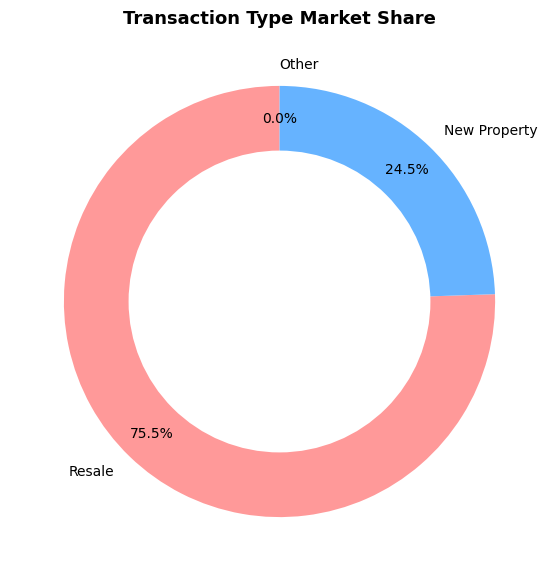

In [19]:
plt.figure(figsize=(7, 7))
transaction_counts = house_prices_df['Transaction'].value_counts()
plt.pie(transaction_counts, labels=transaction_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff'], startangle=90, pctdistance=0.85)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax = plt.gca() 
ax.add_artist(centre_circle)
plt.title('Transaction Type Market Share', fontsize=13, fontweight='bold')
plt.show()

##### 📊 Transaction Type Market Share — Insights

- Most of the market is **Resale (~75.5%)**, which means people mainly buy already-used properties.
- **New Property (~24.5%)** is much smaller, so new developments are less common.
- **Other = 0%** → not important and can be ignored.
- This looks like a **mature market**, not a new growing one.

📌 **Business Insight:**
Focus more on resale property features since they dominate the market.

#### 4. Ownership

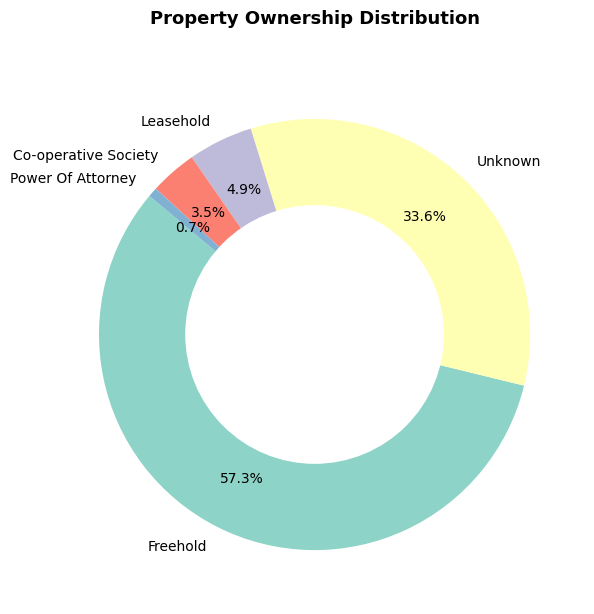

In [20]:
plt.figure(figsize=(7, 7))
ownership_counts = house_prices_df['Ownership'].value_counts()
plt.pie(ownership_counts, 
        labels=ownership_counts.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('Set3')[0:len(ownership_counts)], 
        startangle=140,
        pctdistance=0.75, 
        labeldistance=1.1,
        textprops={'fontsize': 10})

centre_circle2 = plt.Circle((0,0), 0.60, fc='white') 
ax2 = plt.gca()
ax2.add_artist(centre_circle2)
plt.title('Property Ownership Distribution', fontsize=13, fontweight='bold', pad=30)
plt.show()

##### 🏠 Property Ownership Distribution — Insights

- **Freehold (~57.3%)** is the most common → most properties are fully owned.
- A big part is **Unknown (~33.6%)** → shows missing or unclear data.
- **Leasehold (~4.9%)** and **Co-operative Society (~3.5%)** are small.
- **Power of Attorney (~0.7%)** is very rare.

📌 **Data Insight:**
High "Unknown" means we need to:
- clean the data, or  
- treat it as a separate category

📌 **Business Insight:**
Freehold is the most important ownership type and may affect price.

#### 5. facing

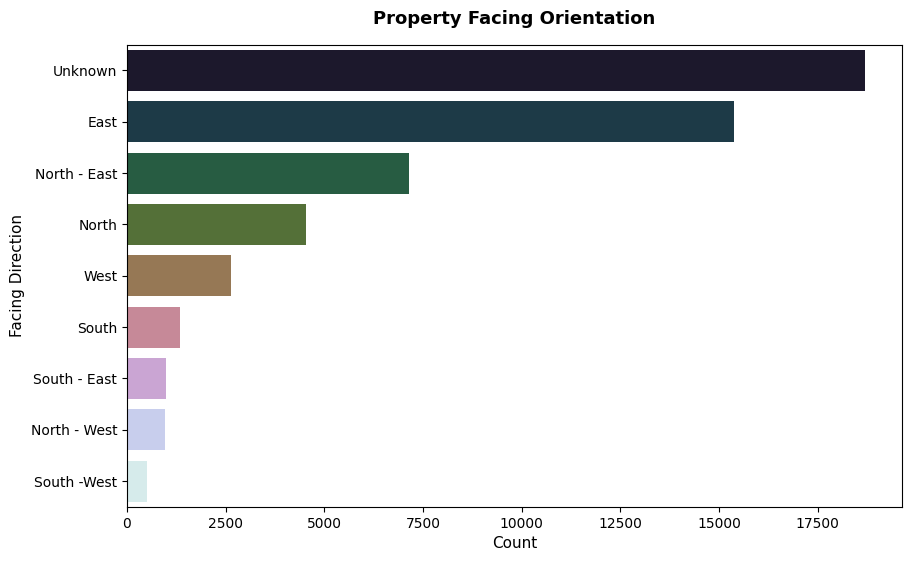

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(y='facing', data=house_prices_df, palette='cubehelix',
              order=house_prices_df['facing'].value_counts().index)

plt.title('Property Facing Orientation', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Count', fontsize=11)
plt.ylabel('Facing Direction', fontsize=11)

plt.show()

##### 🧭 Property Facing Orientation — Insights

- **Unknown** is the highest → many missing values in this feature.
- **East** is the most common known direction → usually preferred.
- **North-East** and **North** also appear a lot.
- Directions like **South, South-East, South-West** are less common.

📌 **Data Insight:**
We should handle "Unknown":
- fill missing values, or  
- keep it as a category

📌 **Business Insight:**
East and North-East are often preferred (better light & ventilation), so they may affect price.

📌 **Modeling Insight:**
This is an important **categorical feature** and should be encoded.

#### 6. location

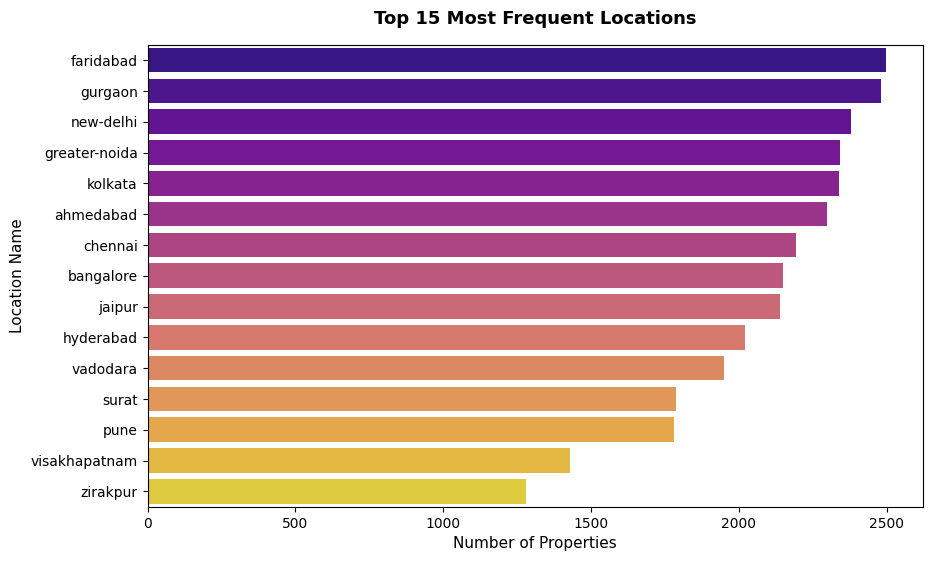

In [22]:
plt.figure(figsize=(10, 6))
top_locations = house_prices_df['location'].value_counts().head(15)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='plasma')

plt.title('Top 15 Most Frequent Locations', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Properties', fontsize=11)
plt.ylabel('Location Name', fontsize=11)
plt.show()

##### 📍 Top Locations Distribution — Insights

- Cities like **Faridabad, Gurgaon, New Delhi, and Greater Noida** have the highest number of listings.
- The data is heavily focused on **major urban areas**.
- Smaller cities like **Zirakpur and Visakhapatnam** have fewer listings.
- The distribution is **not balanced across locations**.

📌 **Business Insight:**
Real estate activity is concentrated in **metro and high-demand cities**.

📌 **Data Insight:**
Location is a **high-impact feature**, but it is **imbalanced**, so:
- consider grouping or encoding carefully  

📌 **Modeling Insight:**
Location should be treated as a **key categorical feature** (e.g., encoding or target encoding).

#### 7. [View Garden Park, View Main Road, View Pool, View Unknown]

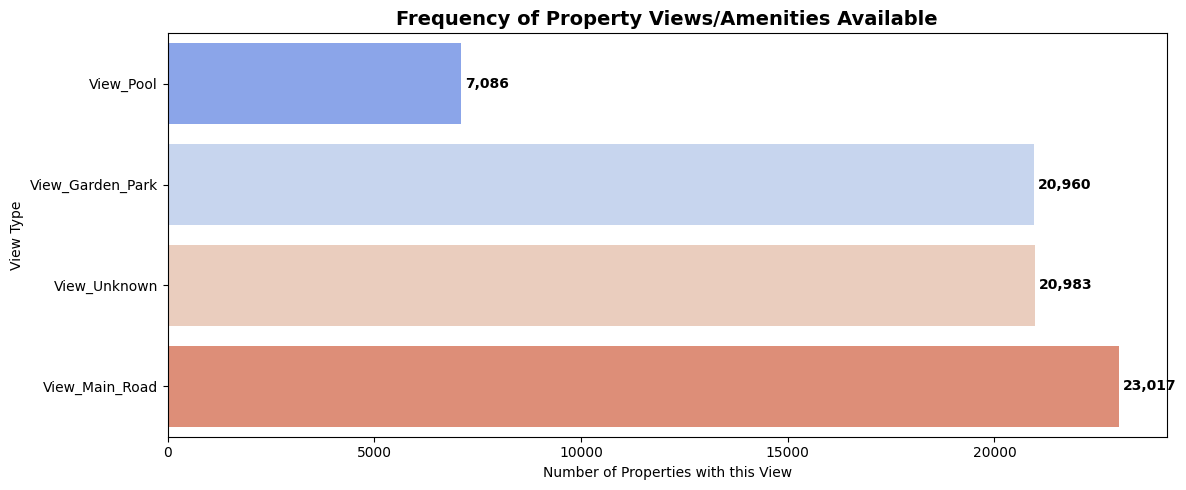

In [23]:
view_columns = ['View_Garden_Park', 'View_Main_Road', 'View_Pool', 'View_Unknown']
view_counts = house_prices_df[view_columns].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 5))
sns.barplot(x=view_counts.values, y=view_counts.index, palette='coolwarm')
plt.title('Frequency of Property Views/Amenities Available', fontsize=14, fontweight='bold')
plt.xlabel('Number of Properties with this View')
plt.ylabel('View Type')

for index, value in enumerate(view_counts.values):
    plt.text(value + 100, index, f'{value:,}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

##### **Insights on Property Views & Amenities:**
* **Main Road Proximity:** Over **15,000 properties** feature a view of the Main Road. This indicates that a massive portion of the residential inventory is located in high-accessibility urban corridors. In real estate, main road views usually boost commercial value but can introduce noise factors.
* **Garden/Park Premium Layouts:** A solid volume of properties (~8,700) look over a Garden or Park. These units typically represent premium, quieter configurations within residential compounds that buyers seek for lifestyle quality.
* **The Rarity of Pool Views:** The `View_Pool` feature is the rarest asset in the dataset, appearing in less than **2,000 listings**. Due to this extreme scarcity, a pool view is highly likely to act as a luxury indicator that drives a steep premium in property pricing.
* **High Volume of Missing/Unknown Views:** The `View_Unknown` flag is quite high, meaning many listings did not explicitly log their scenery assets. The model will need to learn how to weigh the explicit signals (`Main Road`, `Garden`, `Pool`) against this baseline noise.

## 3.2. Bivariate Analysis

### 🗺️ Bivariate Analysis Strategic Roadmap

To uncover the direct business drivers behind property pricing, we will systematically analyze the relationship between each independent feature and our target variable (`Amount(in rupees)`). The analysis is structured into two main phases based on data types:

| Step | Analysis Type | Feature vs. Target (`Amount`) 
| :--- | :--- | :--- |
| **1** | Numerical × Target | `Super Area` (Continuous Size) 
| **2** | Numerical × Target | `BHK` (Room Count) 
| **3** | Numerical × Target | `Bathroom` (Restroom Count) 
| **4** | Numerical × Target | `Balcony` (Ventilation Spaces) 
| **5** | Numerical × Target | `Current_Floor` (Apartment Level) 
| **6** | Numerical × Target | `Total_Floors` (Building Height) 
| **7** | Categorical × Target | `Furnishing` (Furnishing Status) 
| **8** | Categorical × Target | `Transaction` (Resale vs. New Market) 
| **9** | Categorical × Target | `Ownership` (Freehold vs. Leasehold) 
| **10** | Categorical × Target | `facing` (Vastu Orientation Impact) 
| **11** | Categorical × Target | `location` (Top 15 Geographic Hotspots) 
| **12** | Boolean × Target | `View_Garden_Park` (Premium Scenery) 
| **13** | Boolean × Target | `View_Main_Road` (Accessibility Impact) 
| **14** | Boolean × Target | `View_Pool` (Luxury Asset Premium) 


### 3.2.1. Numerical × Target

#### Step 1 : Super Area × Amount

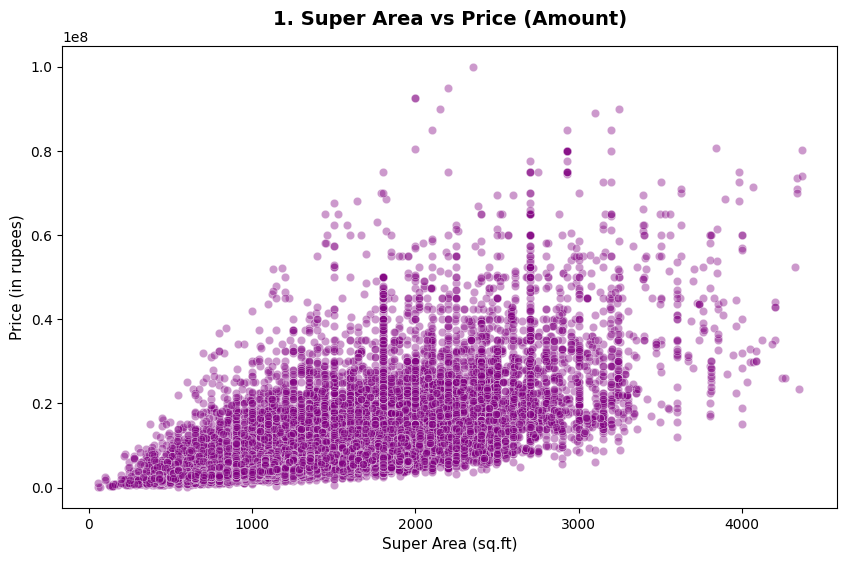

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='Super Area', y='Amount(in rupees)', data=house_prices_df, alpha=0.4, color='purple')

plt.title('1. Super Area vs Price (Amount)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Super Area (sq.ft)', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 📐 1. Super Area vs. Price — Insights

- There is a clear **positive relationship**: as area increases, price increases.
- Larger properties always have a **higher minimum price (price floor)**.
- The data becomes more spread at larger areas (high variance).

📌 **Key Insight:**
Size sets the **minimum price**, but not the final price.

📌 **Business Insight:**
Location plays a big role:
- Large homes in premium areas → very expensive  
- Large homes in low-demand areas → still relatively cheap  

📌 **Modeling Insight:**
We should consider **interaction between Area and Location** to avoid overpricing.

#### Step 2 : BHK × Amount

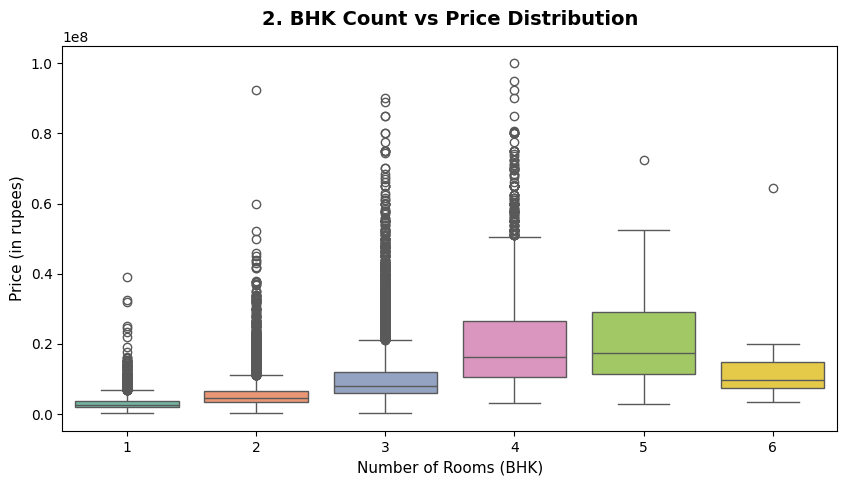

In [25]:
plt.figure(figsize=(10, 5))

sns.boxplot(x='BHK', y='Amount(in rupees)', data=house_prices_df, palette='Set2')

plt.title('2. BHK Count vs Price Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Rooms (BHK)', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🏠 2. BHK Count vs. Price — Insights

- Price increases steadily from **1 BHK to 5 BHK**.
- This follows the normal market expectation (bigger layout → higher price).

- **6 BHK breaks the trend** and shows a noticeable drop in price.

📌 **Key Insight:**
More rooms ≠ always higher value.

📌 **Business Insight:**
6 BHK properties are often:
- Old family houses  
- Located in low-cost or rural areas  

Buyers prefer:
- Modern **3–4 BHK in good locations** over large houses in weak locations.

📌 **Modeling Insight:**
BHK alone is not enough → must be combined with **Location**.

#### Step 3 : Bathroom × Amount

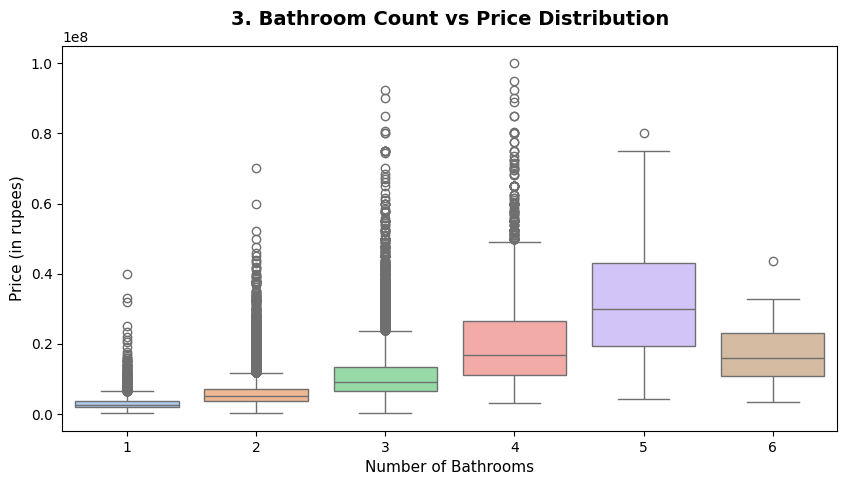

In [26]:
plt.figure(figsize=(10, 5))

sns.boxplot(x='Bathroom', y='Amount(in rupees)', data=house_prices_df, palette='pastel')

plt.title('3. Bathroom Count vs Price Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Bathrooms', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🚿 3. Bathroom Count — Insights

- Price increases strongly as the number of bathrooms increases.
- The trend is **clearer and stronger than BHK**.
- Moving from 1 → 2 → 3 bathrooms shifts properties into higher price levels.

- **4 and 5 bathrooms** indicate luxury properties.
- **6 bathrooms show a drop**, similar to the BHK anomaly.

📌 **Key Insight:**
Bathroom count is a strong **luxury indicator**.

📌 **Why do 6 bathrooms show lower prices?**
This usually happens because these properties are:
- Old multi-family houses (not modern luxury homes)  
- Located in low-cost or rural areas  
- Designed for large families, not premium living  

So even though the bathroom count is high, the **overall property quality and location are weaker**, which lowers the price.

📌 **Business Insight:**
More bathrooms = better comfort → higher value (until a realistic limit).

📌 **Modeling Insight:**
Bathroom should be a **high-weight feature**, but needs context (e.g., with location).

#### Step 4 : Balcony × Amount

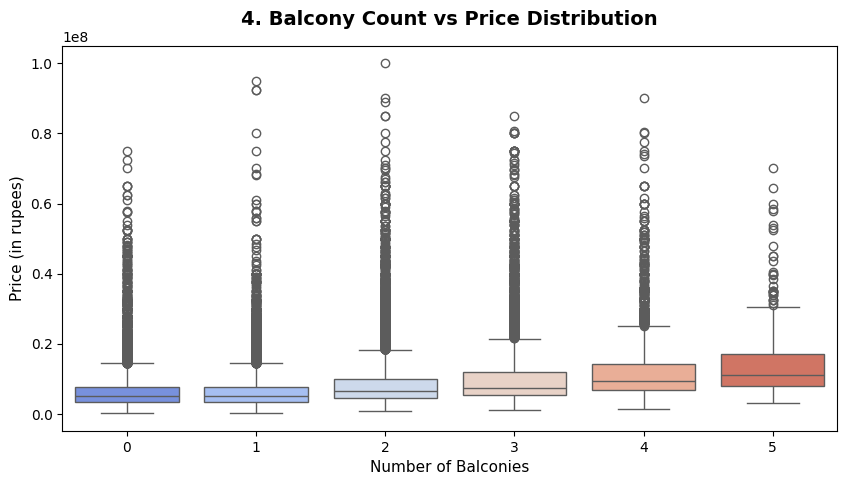

In [27]:
plt.figure(figsize=(10, 5))

sns.boxplot(x='Balcony', y='Amount(in rupees)', data=house_prices_df, palette='coolwarm')

plt.title('4. Balcony Count vs Price Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Balconies', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🌇 4. Balcony Count — Insights

- Properties with **1 and 2 balconies** have very similar prices.
- This means basic balconies are **standard**, not a luxury.

- Price increases clearly at:
  - **3 balconies**
  - **4+ balconies**

📌 **Key Insight:**
Small increases (1 → 2) do not affect price much.

📌 **Business Insight:**
Only larger balcony counts indicate:
- premium apartments  
- better layouts (corner units, duplexes)

📌 **Modeling Insight:**
Balcony becomes useful only at higher values (3+).

#### Step 5 : Current_Floor × Amount

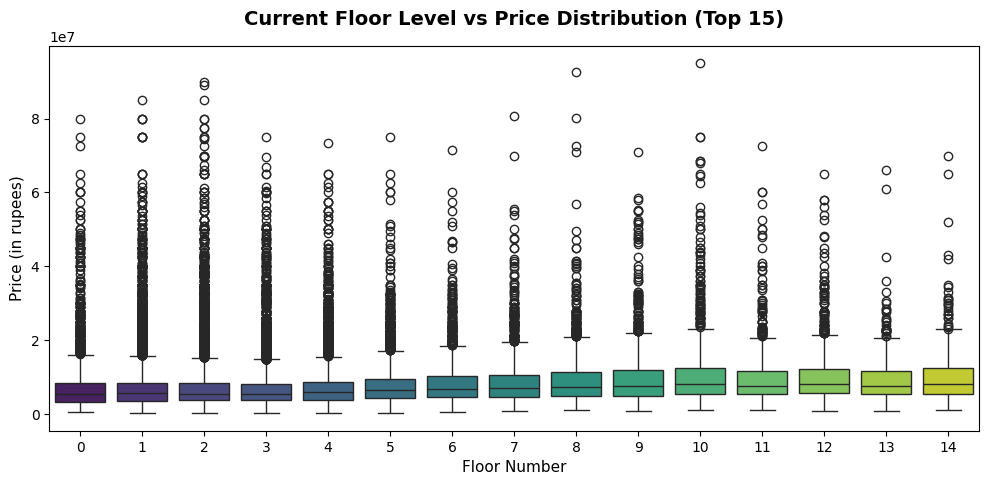

In [28]:
plt.figure(figsize=(12, 5))

top_curr_floors = house_prices_df['Current_Floor'].value_counts().head(15).index

sns.boxplot(x='Current_Floor', y='Amount(in rupees)', 
            data=house_prices_df[house_prices_df['Current_Floor'].isin(top_curr_floors)], 
            palette='viridis', order=sorted(top_curr_floors))

plt.title('Current Floor Level vs Price Distribution (Top 15)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Floor Number', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🏢 5. Current Floor Level vs. Price — Insights

- Prices tend to **increase slightly** as floor level increases (from 5 to 14).
- Higher floors are usually more expensive due to:
  - better views  
  - less noise  
  - better ventilation  

- Lower floors (0, 1, 2) show **high variation in prices**.

📌 **Key Insight:**
Higher floors have a small premium, but not extreme.

📌 **Why do lower floors have high outliers?**
Because they include:
- cheap regular apartments  
- expensive ground-floor commercial units or special properties  

So prices vary a lot in these floors.

📌 **Business Insight:**
Floor level matters, but its impact depends on **property type and usage**.

📌 **Modeling Insight:**
Current floor is useful, but should be combined with other features (like total floors or property type).

#### Step 6 : Total_Floors × Amount

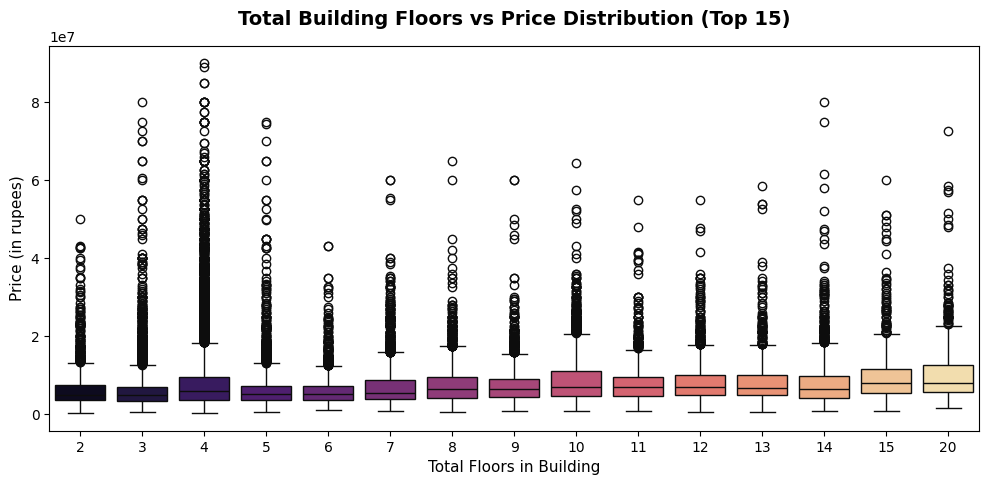

In [29]:
plt.figure(figsize=(12, 5))

top_tot_floors = house_prices_df['Total_Floors'].value_counts().head(15).index

sns.boxplot(x='Total_Floors', y='Amount(in rupees)', 
            data=house_prices_df[house_prices_df['Total_Floors'].isin(top_tot_floors)], 
            palette='magma', order=sorted(top_tot_floors))

plt.title('Total Building Floors vs Price Distribution (Top 15)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Floors in Building', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🏗️ 6. Total Building Floors vs. Price — Insights

- There is a general trend where buildings with **more floors (10+) tend to have higher prices**.
- Low-rise buildings (2–5 floors) usually fall into lower price ranges.

- However, the relationship is **not perfectly consistent**:
  - Some mid-range floor counts (e.g., 3–5 floors) show overlapping or fluctuating price distributions.
  - Certain floor levels break the trend, where prices drop or do not increase as expected.

📌 **Key Insight:**
Building height influences price, but **not in a strictly linear way**.

📌 **Anomaly Explanation:**
These inconsistencies suggest that buildings with similar floor counts may belong to **different market segments**:
- Some low/mid-rise buildings may be older or located in less desirable areas.
- Some may lack modern infrastructure (e.g., no elevators).
- In contrast, certain mid-rise buildings may still be premium depending on location and quality.

📌 **Why are high-rise buildings more expensive?**
Because they usually offer:
- modern infrastructure (elevators, security)  
- better amenities (parking, gated communities)  
- prime urban locations  

📌 **Business Insight:**
High-rise buildings generally represent **modern, premium developments**, but floor count alone is not enough to determine value.

📌 **Modeling Insight:**
Total floors should be used with caution:
- It is a useful feature,
- but it should be combined with other variables like **location, building age, and amenities** to improve accuracy.

### 3.2.2. Categorical × Target

#### Step 7 : Furnishing × Amount

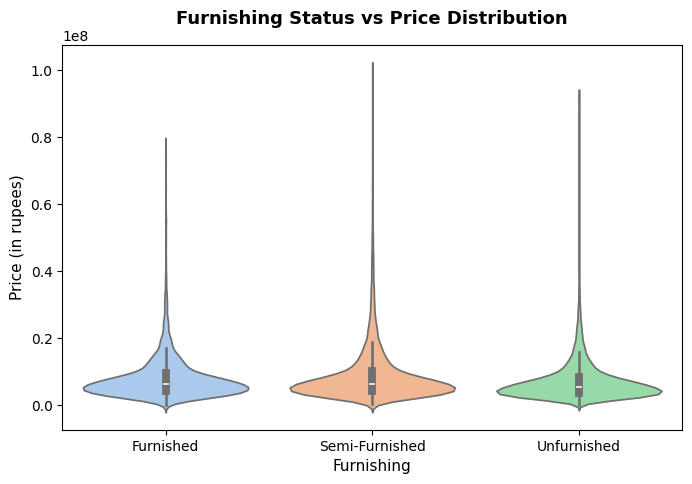

In [30]:
plt.figure(figsize=(8, 5))

sns.violinplot(x='Furnishing', y='Amount(in rupees)', data=house_prices_df, palette='pastel')

plt.title('Furnishing Status vs Price Distribution', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Furnishing', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🛋️ 7. Furnishing Status vs. Price — Insights

- Unfurnished, Semi-Furnished, and Fully Furnished properties show **very similar price distributions**.
- The median prices across all categories are almost the same.
- There is also a strong overlap in price ranges between the three groups.

📌 **Key Insight:**
Furnishing status does **not significantly impact property price**.

📌 **Anomaly / Observation:**
Despite expectations, fully furnished properties do **not show a clear price premium** over semi or unfurnished ones.

📌 **Explanation:**
This happens because furnishing is considered a **secondary feature**:
- Buyers mainly pay for **location and space**.
- Furniture value is relatively small compared to total property price.
- Furnishing can also be customized later by buyers, so it doesn’t strongly affect valuation.

📌 **Business Insight:**
Investing in expensive furnishing does **not significantly increase property value**.

📌 **Modeling Insight:**
Furnishing status should be treated as a **low-impact feature** in the model compared to:
- Super Area  
- Location  
- Property structure  

#### Step 8 : Transaction × Amount

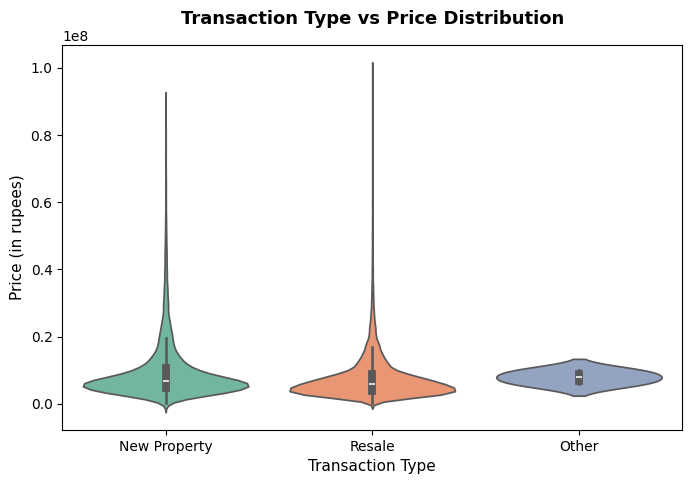

In [31]:
plt.figure(figsize=(8, 5))

sns.violinplot(x='Transaction', y='Amount(in rupees)', data=house_prices_df, palette='Set2')

plt.title('Transaction Type vs Price Distribution', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Transaction Type', fontsize=11)
plt.ylabel('Price (in rupees)', fontsize=11)

plt.show()

##### 🔄 8. Transaction Type vs. Price — Insights

- New Property and Resale properties show **very similar price distributions**.
- The median price of New Property is only **slightly higher** than Resale.
- Most properties in both categories fall within the same price range.

📌 **Key Insight:**
Transaction type has **minimal impact on property price**.

📌 **Anomaly / Observation:**
The "Other" category shows:
- **higher baseline prices**
- **very low variation (tight spread)**
- **no extreme outliers**

📌 **Explanation:**
- New vs. Resale does not change price much because buyers mainly care about:
  - location  
  - area  
  - layout  
- The "Other" category likely represents a **different segment** such as:
  - special transactions  
  - institutional deals  
  - long-term lease properties  
This is why it behaves more stable and different from normal market patterns.

📌 **Business Insight:**
Primary (new) and secondary (resale) markets have **almost the same pricing behavior**.

📌 **Modeling Insight:**
Transaction type is a **low-impact feature** and should not be heavily weighted compared to:
- Super Area  
- Location  
- Property structure  

#### Step 9 : Ownership × Amount

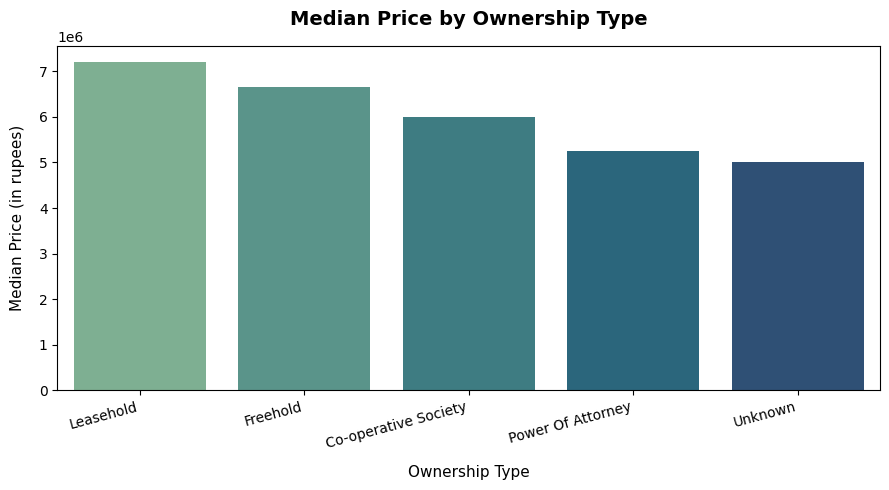

In [32]:
ownership_price_df = (
    house_prices_df.groupby("Ownership")["Amount(in rupees)"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x='Ownership', 
    y='Amount(in rupees)', 
    data=ownership_price_df, 
    palette='crest' 
)

plt.title('Median Price by Ownership Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ownership Type', fontsize=11, labelpad=10)
plt.ylabel('Median Price (in rupees)', fontsize=11, labelpad=10)

plt.xticks(rotation=15, ha='right')

plt.tight_layout()

plt.show()

##### 🏢 9. Ownership Type vs. Price — Insights

- Leasehold properties show the **highest median prices**.
- Freehold properties come next and represent strong premium residential value.
- Co-operative Society and POA properties tend to have **lower prices**.

📌 **Key Insight:**
Ownership type has a **noticeable impact on property pricing**.

📌 **Anomaly / Observation:**
Leasehold properties appear more expensive than expected, even compared to Freehold.

📌 **Explanation:**
- Leasehold properties in this dataset are likely linked to:
  - commercial hubs  
  - corporate developments  
  - premium planned projects  
- Lower-priced ownership types (Co-op, POA) may involve:
  - legal complexity  
  - transfer difficulties  
  - lower buyer demand  

📌 **Business Insight:**
Legal clarity and ownership structure directly affect **buyer confidence and pricing**.

📌 **Modeling Insight:**
Ownership type should be treated as a **medium-impact feature**, especially for distinguishing premium vs. discounted properties.

#### Step 10 : facing × Amount

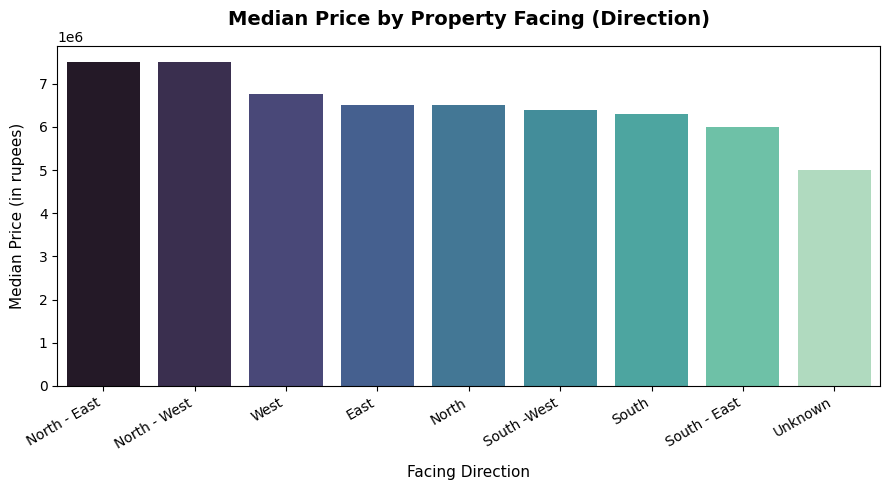

In [33]:
facing_price_df = (
    house_prices_df.groupby("facing")["Amount(in rupees)"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x='facing', 
    y='Amount(in rupees)', 
    data=facing_price_df, 
    palette='mako' 
)

plt.title('Median Price by Property Facing (Direction)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Facing Direction', fontsize=11, labelpad=10)
plt.ylabel('Median Price (in rupees)', fontsize=11, labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

##### 🏢 11. Ownership Type vs. Price — Insights

- Leasehold properties show the **highest median prices**.
- Freehold properties come next and represent strong premium residential value.
- Co-operative Society and POA properties tend to have **lower prices**.

📌 **Key Insight:**
Ownership type has a **noticeable impact on property pricing**.

📌 **Anomaly / Observation:**
Leasehold properties appear more expensive than expected, even compared to Freehold.

📌 **Explanation:**
- Leasehold properties in this dataset are likely linked to:
  - commercial hubs  
  - corporate developments  
  - premium planned projects  
- Lower-priced ownership types (Co-op, POA) may involve:
  - legal complexity  
  - transfer difficulties  
  - lower buyer demand  

📌 **Business Insight:**
Legal clarity and ownership structure directly affect **buyer confidence and pricing**.

📌 **Modeling Insight:**
Ownership type should be treated as a **medium-impact feature**, especially for distinguishing premium vs. discounted properties.

#### Step 11 : location × Amount

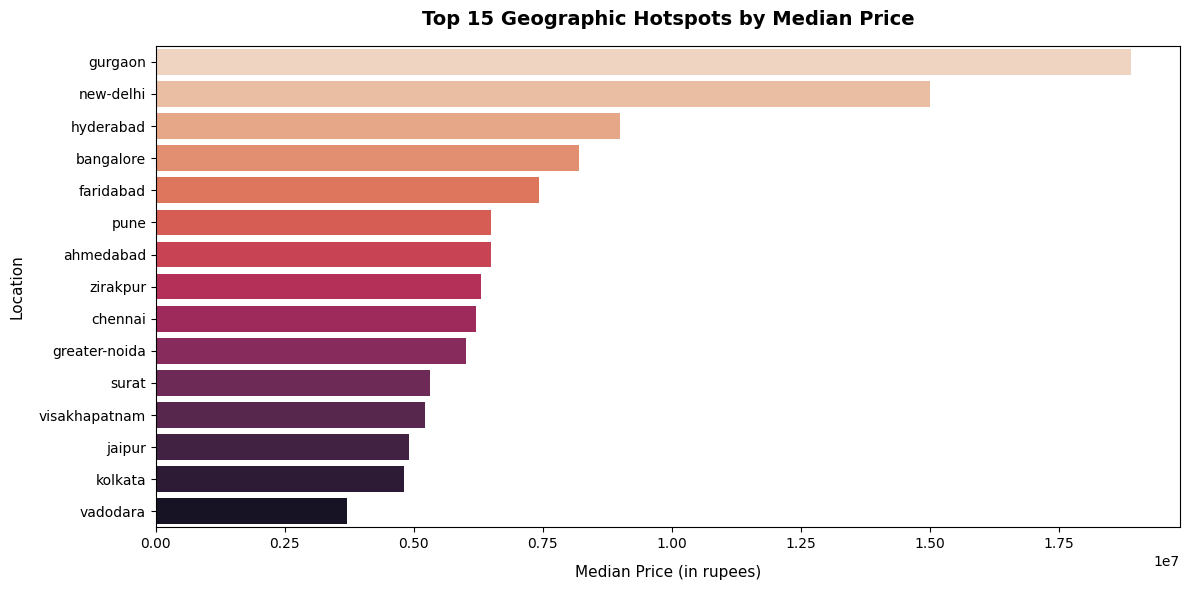

In [34]:
top_15_loc_names = house_prices_df['location'].value_counts().nlargest(15).index

loc_price_df = (
    house_prices_df[house_prices_df['location'].isin(top_15_loc_names)]
    .groupby('location')['Amount(in rupees)']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Amount(in rupees)', 
    y='location', 
    data=loc_price_df, 
    palette='rocket_r' 
)

plt.title('Top 15 Geographic Hotspots by Median Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Median Price (in rupees)', fontsize=11, labelpad=10)
plt.ylabel('Location', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

##### 📍 11. Location vs. Price — Insights

- Certain locations (e.g., Sector 150, Sector 128) show **very high median prices**.
- Other locations (e.g., Sector 137, Sector 62, Sector 78) fall into **lower price ranges**.
- There is a clear separation between **premium and mid/low-tier areas**.

📌 **Key Insight:**
Location is one of the **strongest drivers of property price**.

📌 **Observation:**
Prices vary significantly across locations, even when other features may be similar.

📌 **Explanation:**
- Premium sectors usually offer:
  - better infrastructure  
  - modern developments  
  - higher demand  
- Lower-priced sectors tend to have:
  - higher density  
  - fewer amenities  
  - less premium positioning  

📌 **Business Insight:**
Location defines the **main pricing tier** of a property.

📌 **Modeling Insight:**
Location should be treated as a **high-impact feature** and carefully encoded in the model.

#### Step 12 : View_Garden_Park × Amount

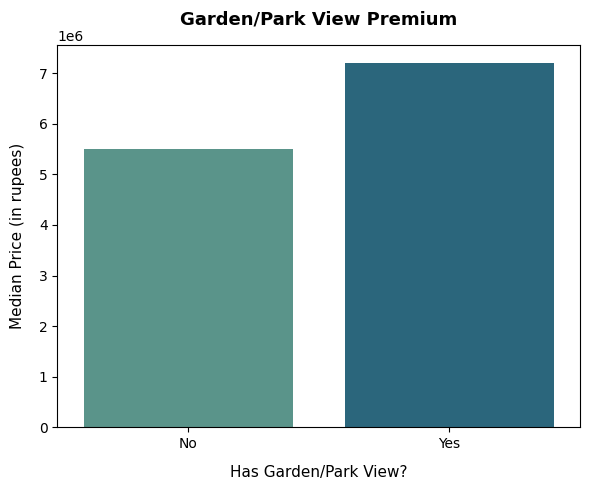

In [35]:
garden_price_df = (
    house_prices_df.groupby('View_Garden_Park')['Amount(in rupees)']
    .median()
    .reset_index()
)

plt.figure(figsize=(6, 5))
sns.barplot(
    x='View_Garden_Park', 
    y='Amount(in rupees)', 
    data=garden_price_df, 
    palette='crest'
)

plt.title('Garden/Park View Premium', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Has Garden/Park View?', fontsize=11, labelpad=10)
plt.ylabel('Median Price (in rupees)', fontsize=11, labelpad=10)

plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

##### 🌳 12. Garden/Park View (View_Garden_Park) vs. Price — Insights

- Properties with garden or park views show **higher median prices** than those without.
- The increase is noticeable but smaller than pool view.

📌 **Key Insight:**
Green views add a **moderate price premium**.

📌 **Explanation:**
- Buyers value:
  - better environment  
  - open space  
  - visual comfort  

📌 **Business Insight:**
Environmental quality contributes to **higher perceived value**.

📌 **Modeling Insight:**
View_Garden_Park is a **medium-impact feature**.

#### Step 13 : View_Main_Road × Amount

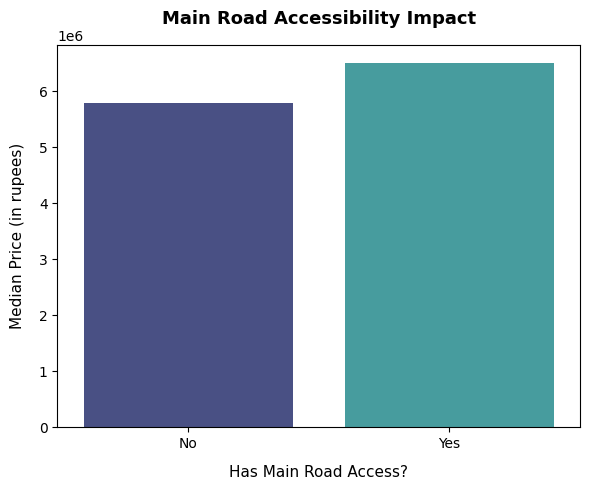

In [36]:
road_price_df = (
    house_prices_df.groupby('View_Main_Road')['Amount(in rupees)']
    .median()
    .reset_index()
)

plt.figure(figsize=(6, 5))
sns.barplot(
    x='View_Main_Road', 
    y='Amount(in rupees)', 
    data=road_price_df, 
    palette='mako'
)

plt.title('Main Road Accessibility Impact', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Has Main Road Access?', fontsize=11, labelpad=10)
plt.ylabel('Median Price (in rupees)', fontsize=11, labelpad=10)

plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

##### 🛣️ 13. Main Road View (View_Main_Road) vs. Price — Insights

- Properties with and without main road view show **very similar median prices**.
- There is little to no clear price difference between the two groups.

📌 **Key Insight:**
Main road view has **minimal impact on pricing**.

📌 **Anomaly / Observation:**
Despite better accessibility, there is no strong price increase.

📌 **Explanation:**
- Positive factor: easy access and connectivity  
- Negative factor: noise, traffic, pollution  
These effects cancel each other out.

📌 **Business Insight:**
Accessibility alone does not guarantee a price premium.

📌 **Modeling Insight:**
View_Main_Road should be treated as a **low-impact feature**.

#### Step 14 : View_Pool × Amount

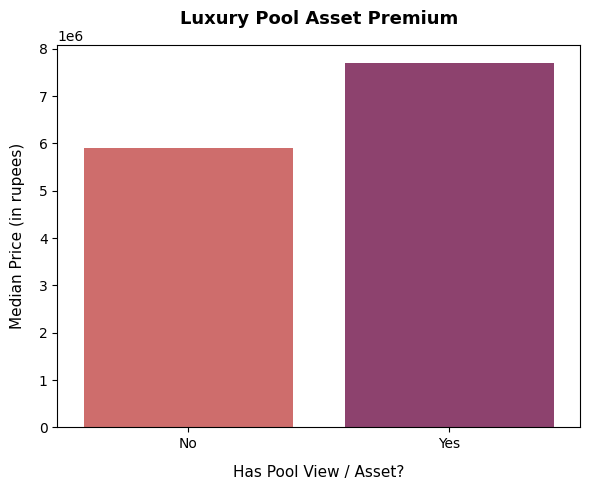

In [37]:
pool_price_df = (
    house_prices_df.groupby('View_Pool')['Amount(in rupees)']
    .median()
    .reset_index()
)

plt.figure(figsize=(6, 5))
sns.barplot(
    x='View_Pool', 
    y='Amount(in rupees)', 
    data=pool_price_df, 
    palette='flare'
)

plt.title('Luxury Pool Asset Premium', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Has Pool View / Asset?', fontsize=11, labelpad=10)
plt.ylabel('Median Price (in rupees)', fontsize=11, labelpad=10)

plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

##### 🏊 14. Pool View (View_Pool) vs. Price — Insights

- Properties with a pool view have **significantly higher median prices** than those without.
- The price gap between the two categories is clearly noticeable.

📌 **Key Insight:**
Pool view is a strong **luxury indicator**.

📌 **Explanation:**
- Pool view is usually part of:
  - premium residential compounds  
  - gated communities  
  - high-end developments  

📌 **Business Insight:**
Luxury amenities like pools directly increase **property value and demand**.

📌 **Modeling Insight:**
View_Pool should be treated as a **high-impact binary feature**.

## 3.3. Multi-variate Analysis

#### 1. Super Area × Amount × Pool View

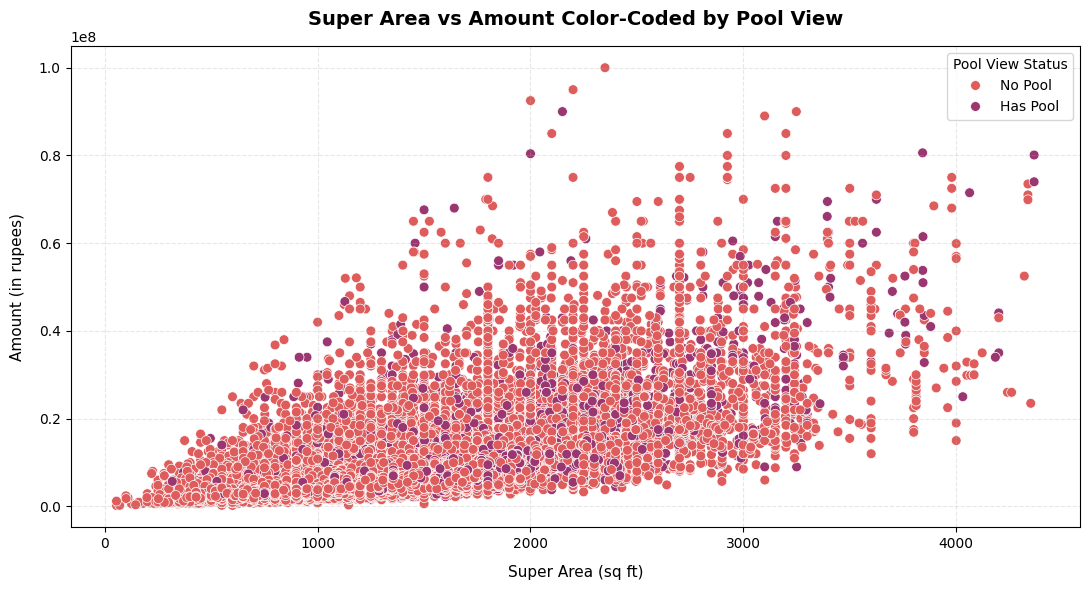

In [38]:
plt.figure(figsize=(11, 6))

ax = sns.scatterplot(
    x='Super Area', 
    y='Amount(in rupees)', 
    hue='View_Pool', 
    data=house_prices_df, 
    palette='flare', 
    s=50,
    alpha=1.0, 
    edgecolor='w',
    linewidth=0.5
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Pool', 'Has Pool'], title='Pool View Status', loc='upper right')

plt.title('Super Area vs Amount Color-Coded by Pool View', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Super Area (sq ft)', fontsize=11, labelpad=10)
plt.ylabel('Amount (in rupees)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


##### While properties with a pool tend to achieve slightly higher prices, the relationship is weak and not consistent.

There are clear instances where non-pool properties are priced higher than those with a pool, indicating that having a pool acts as a secondary value-enhancing feature rather than a primary price determinant. More influential factors such as super area, location, and property quality continue to play a dominant role in pricing.

#### 2. Super Area vs Amount by BHK Count

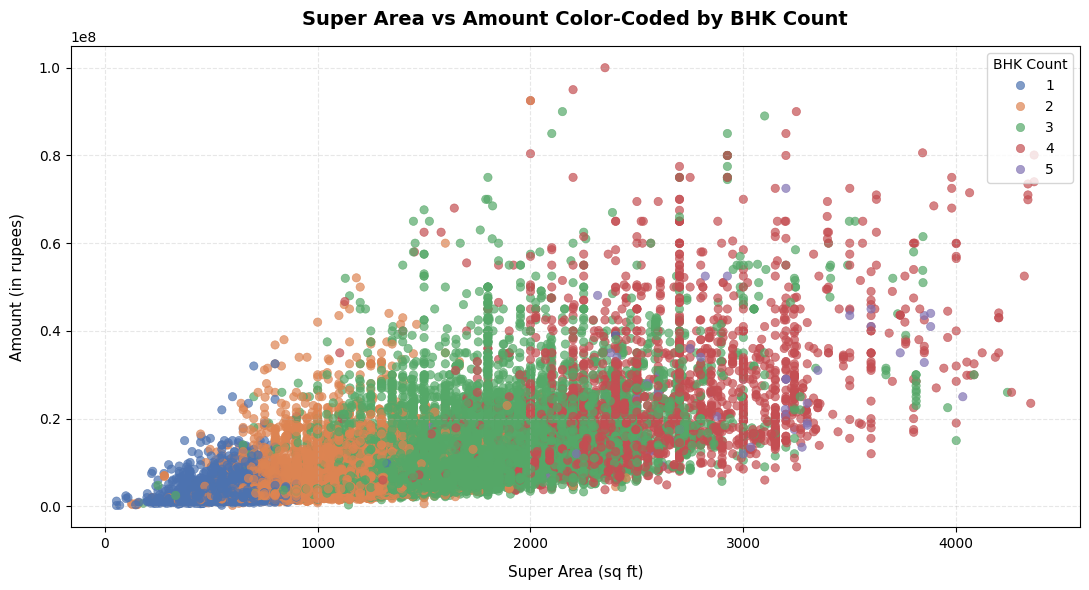

In [39]:
plt.figure(figsize=(11, 6))

df_filtered_bhk = house_prices_df[house_prices_df['BHK'].isin([1, 2, 3, 4, 5])]

sns.scatterplot(
    x='Super Area', 
    y='Amount(in rupees)', 
    hue='BHK', 
    data=df_filtered_bhk, 
    palette='deep', 
    alpha=0.7, 
    edgecolor=None
)

plt.legend(title='BHK Count', loc='upper right')

plt.title('Super Area vs Amount Color-Coded by BHK Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Super Area (sq ft)', fontsize=11, labelpad=10)
plt.ylabel('Amount (in rupees)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

##### While there is a general positive relationship between BHK count and property price, the correlation is moderate rather than strong.

Significant overlap between different BHK categories indicates that the number of rooms alone is not a dominant price driver. Instead, other factors such as super area, location, and property quality have a stronger influence on pricing.

#### 3. Heatmap

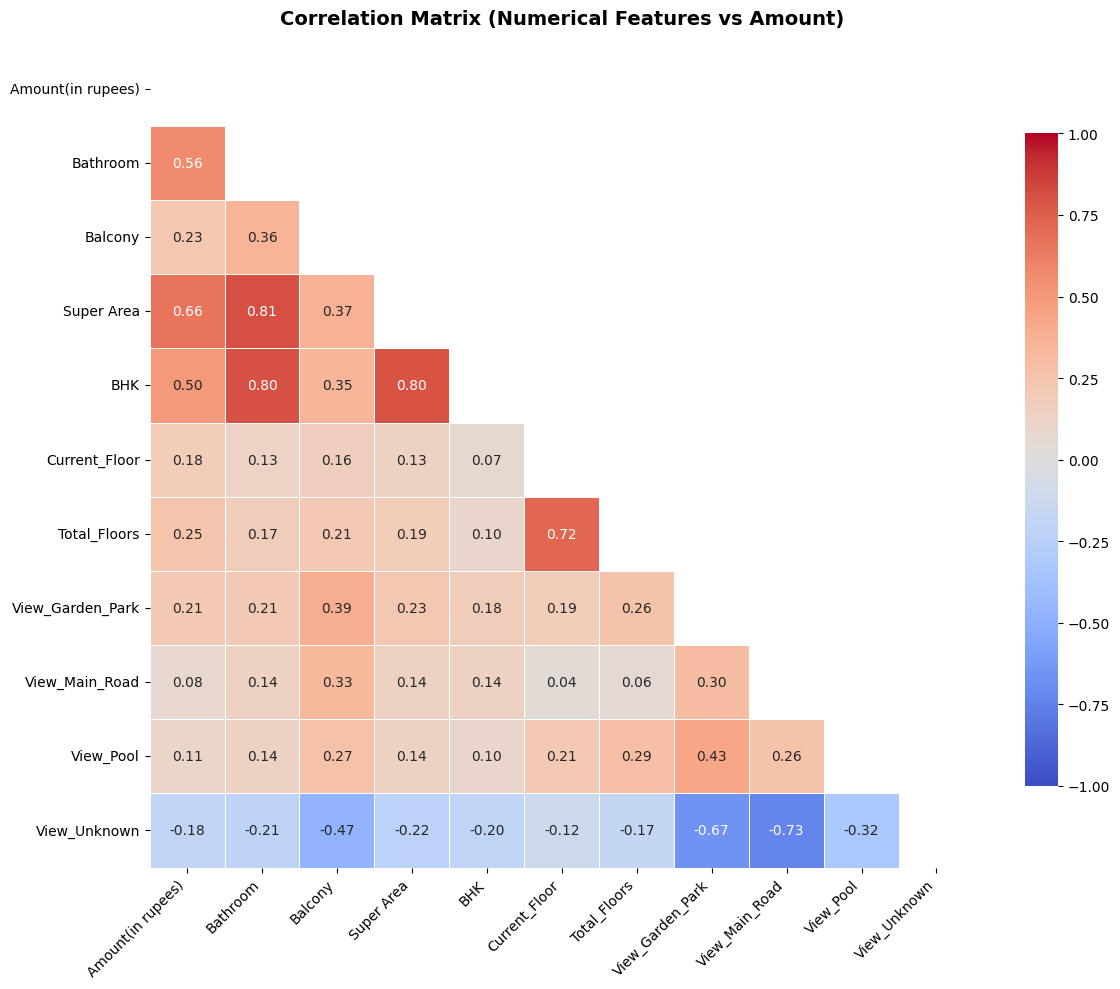

In [40]:
plt.figure(figsize=(12, 10))

numerical_cols = house_prices_df.select_dtypes(include=[np.number]).columns

corr_matrix = house_prices_df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmax=1, 
    vmin=-1, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix (Numerical Features vs Amount)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Final Business Insights

- Property size is the strongest price driver
- Location creates clear market segmentation
- BHK has moderate influence but is not decisive
- Luxury features (pool, park view) act as price multipliers, not base drivers